# Financial Fraud Detection - Data Cleaning and Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('data/Financial_dataset.csv')
print('Original shape:', df.shape)
df.head()

Original shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


--- 
# Checking for missing Values

In [4]:
print('Missing values:')
df.isnull().sum()

Missing values:


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

## Check for Duplicates

In [5]:
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 0


--- 
# Dropping Unnecessary Columns

In [6]:
print(f'Unique nameOrig values: {df["nameOrig"].nunique()}')
print(f'Unique nameDest values: {df["nameDest"].nunique()}')
print(f'isFlaggedFraud total flagged: {df["isFlaggedFraud"].sum()}')

Unique nameOrig values: 6353307
Unique nameDest values: 2722362
isFlaggedFraud total flagged: 16


In [7]:
df = df.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud'])
print('Shape after dropping columns:', df.shape)
print(df.columns.tolist())

Shape after dropping columns: (6362620, 8)
['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']


--- 
# Feature Engineering

In [8]:
# Did the origin account balance go to zero?
df['orig_balance_drained'] = (df['newbalanceOrig'] == 0).astype(int)

# Difference between expected and actual balance change at origin
df['orig_balance_error'] = df['oldbalanceOrg'] - df['newbalanceOrig'] - df['amount']

# Same check for destination
df['dest_balance_error'] = df['newbalanceDest'] - df['oldbalanceDest'] - df['amount']

print('New features added:')
print(df[['orig_balance_drained', 'orig_balance_error', 'dest_balance_error']].describe())

New features added:
       orig_balance_drained  orig_balance_error  dest_balance_error
count          6.362620e+06        6.362620e+06        6.362620e+06
mean           5.673081e-01       -2.010925e+05       -5.556717e+04
std            4.954489e-01        6.066505e+05        4.415288e+05
min            0.000000e+00       -9.244552e+07       -1.319123e+07
25%            0.000000e+00       -2.496411e+05       -2.935305e+04
50%            1.000000e+00       -6.867726e+04       -3.500490e+03
75%            1.000000e+00       -2.954230e+03        0.000000e+00
max            1.000000e+00        1.000000e-02        7.588573e+07


---
# One-Hot Encoding Transaction Type

In [9]:
df = pd.get_dummies(df, columns=['type'])

# Convert boolean columns to int
type_cols = [col for col in df.columns if col.startswith('type_')]
for col in type_cols:
    df[col] = df[col].astype(int)

print('Shape after encoding:', df.shape)
print(df.columns.tolist())

Shape after encoding: (6362620, 15)
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'orig_balance_drained', 'orig_balance_error', 'dest_balance_error', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


---
# Check for Outliers

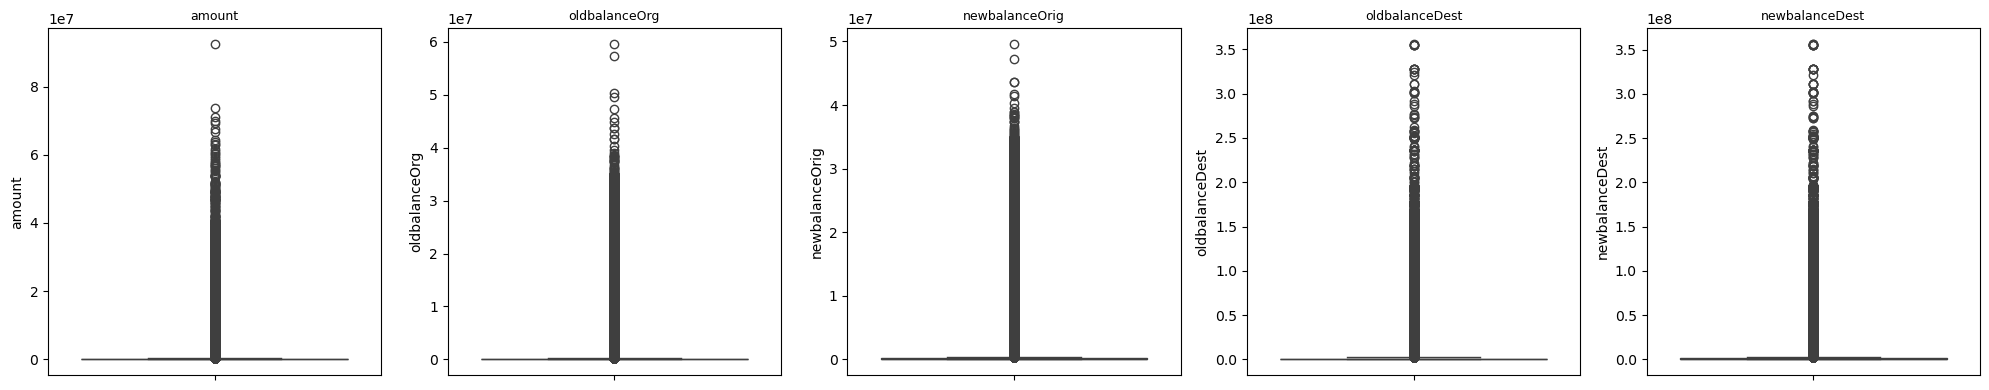

In [10]:
numerical_features = ['amount', 'oldbalanceOrg', 'newbalanceOrig',
                       'oldbalanceDest', 'newbalanceDest']

fig, axes = plt.subplots(1, len(numerical_features), figsize=(20, 4))
for i, col in enumerate(numerical_features):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

---
# Save Cleaned Dataset

In [11]:
print('Final shape:', df.shape)
print('Fraud distribution:')
print(df['isFraud'].value_counts())
df.head()

Final shape: (6362620, 15)
Fraud distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,orig_balance_drained,orig_balance_error,dest_balance_error,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,0,1.455192e-11,-9839.64,0,0,0,1,0
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,0,-1.136868e-12,-1864.28,0,0,0,1,0
2,1,181.00,181.0,0.00,0.0,0.0,1,1,0.000000e+00,-181.00,0,0,0,0,1
3,1,181.00,181.0,0.00,21182.0,0.0,1,1,0.000000e+00,-21363.00,0,1,0,0,0
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,0,0.000000e+00,-11668.14,0,0,0,1,0


In [12]:
df.to_csv('data/fraud_cleaned.csv', index=False)
print('Clean dataset saved')

Clean dataset saved
